# 한글 폰트 설치

In [ ]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [ ]:
import matplotlib.pyplot as plt
import platform
import seaborn as sns
import matplotlib.font_manager as fm     # 시스템에 설치된 폰트를 탐색하고 그래프 폰트로 등록해주는 매니저

# 한국어 폰트 설정 ───────────────────────────────────────────────────
font_dirs = ['/usr/share/fonts/truetype/nanum']         # 나눔 폰트가 설치되어 있는 시스템 폴더 경로 지정
font_files = fm.findSystemFonts(fontpaths=font_dirs)    # 지정한 경로에서 폰트 파일(.ttf) 목록을 모두 찾아 리스트로 반환
for ff in font_files:
    fm.fontManager.addfont(ff)                          # 찾은 개별 폰트 파일들을 Matplotlib 폰트 매니저에 사용할 수 있도록 등록

# ── 5. 시각화 전역 설정 (Wilke 스타일 + 폰트 통합) ──────────────────────────────
# Seaborn 테마 설정 (여기에 폰트를 지정해야 sns 그래프에서도 한글이 깨지지 않음)
sns.set_theme(
    style='whitegrid',                  # 배경을 하얗고 옅은 격자가 있는 스타일로 설정
    rc={
        'font.family': 'NanumBarunGothic', # 그래프의 기본 글꼴을 등록해둔 '나눔바른고딕'으로 설정 (한글 깨짐 방지)
        'axes.unicode_minus': False        # 한글 폰트 적용 시 축의 마이너스(-) 기호가 네모로 깨지는 현상 방지
    }
)

# Matplotlib 세부 스타일 설정 (흰 배경, 최소 격자, 고해상도)
plt.rcParams.update({
    'figure.dpi': 130,                  # 그래프의 해상도를 130 DPI로 설정하여 선명하게 출력
    'figure.facecolor': 'white',        # 그래프 바깥쪽 영역(Figure)의 배경색을 흰색으로 설정
    'axes.facecolor': '#FAFAFA',        # 그래프 안쪽 영역(Axes)의 배경색을 아주 옅은 회색으로 설정
    'axes.spines.top': False,           # 그래프의 위쪽 테두리 선을 숨김 (깔끔한 시각화를 위해)
    'axes.spines.right': False,         # 그래프의 오른쪽 테두리 선을 숨김
    'axes.grid': True,                  # 그래프 내부에 격자선을 표시하도록 설정
    'grid.alpha': 0.3,                  # 격자선의 투명도를 0.3으로 설정 (연하게 표시)
    'grid.linestyle': '--',             # 격자선의 모양을 점선(dash)으로 설정
    'axes.titlesize': 13,               # 그래프 제목(Title)의 글씨 크기를 13으로 설정
    'axes.labelsize': 11,               # x축, y축 이름(Label)의 글씨 크기를 11로 설정
    'xtick.labelsize': 9,               # x축 눈금 숫자들의 글씨 크기를 9로 설정
    'ytick.labelsize': 9,               # y축 눈금 숫자들의 글씨 크기를 9로 설정
    'legend.fontsize': 9,               # 범례(Legend)의 글씨 크기를 9로 설정
})

print('라이브러리 로드 및 시각화 환경 설정 완료')

라이브러리 로드 및 시각화 환경 설정 완료


- 테스트

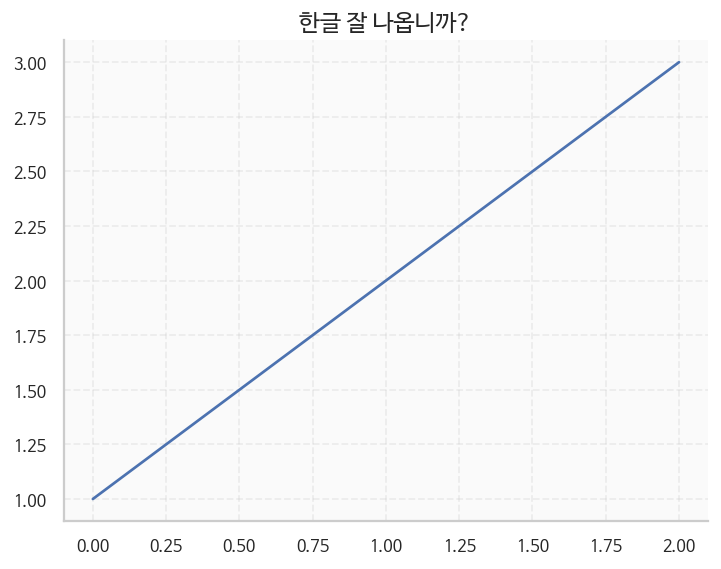

In [ ]:
plt.plot([1, 2, 3])
plt.title("한글 잘 나옵니까?")
plt.show()

# 라이브러리 불러오기
- SARIMAX: 단순한 추세뿐만 아니라 계절적 패턴과 외부 변수까지 포함하여 미래를 예측할 때 사용합니다.
- adfuller: 시계열 분석 전 반드시 거쳐야 하는 단계입니다. 데이터가 "떠돌이(비정상)" 상태인지 "제자리(정상)" 상태인지 수치로 알려줍니다.
- plot_acf: 과거의 자기 자신이 현재에 얼마나 영향을 주는지 시각적으로 보여주며, 모델의 차수($p, q$)를 결정하는 힌트를 줍니다.

In [ ]:
# 1. 시계열 모델 관련
# 코드

# 3. 데이터 처리 및 기본 시각화
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 4. 환경 설정
import warnings
# 모델 학습 중 발생하는 번거로운 경고 메시지(버전 이슈 등)를 화면에서 숨김
warnings.filterwarnings('ignore')

# %matplotlib inline: 주피터 노트북 내부에 그래프가 바로 표시되도록 하는 매직 명령어
%matplotlib inline

# 정상적 ARMA 프로세스
- ARMA(1, 1) 프로세스 시뮬레이션

In [ ]:
# 1. 성능 평가 및 분석 도구 임포트
# 코드

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2. 경고 무시 및 시각화 설정
import warnings
warnings.filterwarnings('ignore') # 불필요한 시스템 경고 숨김
# %matplotlib inline                # 노트북 내 그래프 출력 설정

# 3. 데이터 재현성을 위한 시드 고정
np.random.seed(42)

# 4. ARMA(1, 1) 파라미터 정의 (중요!)
# 수식: y_t = 0.33 * y_{t-1} + ε_t + 0.9 * ε_{t-1}
# statsmodels의 규칙에 따라 AR 계수는 부호를 반대로 입력해야 함 ([1, -phi])
ar1 = np.array([1, -0.33]) # AR(1) 계수: 0.33
ma1 = np.array([1, 0.9])   # MA(1) 계수: 0.9

# 5. 가상의 시계열 샘플 데이터 생성
# nsample=1000: 1000개의 데이터 포인트를 가진 ARMA(1, 1) 시뮬레이션 데이터 생성
ARMA_1_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=1000)

- ADF 검정은 다음과 같은 가설을 기반으로 합니다
    + 귀무가설($H_0$): 데이터가 비정상성(Non-stationary)이다. 즉, 단위근(Unit root)이 존재한다.
    + 대립가설($H_1$): 데이터가 정상성(Stationary)이다.

In [ ]:
# 코드

ADF Statistic: -6.429878682042687
p-value: 1.707846668009726e-08


## 자기상관관계
- 자기 (Auto): 남이 아닌 '과거의 나 자신'을 의미합니다.
- 상관관계 (Correlation): 두 가지가 '얼마나 비슷하게 움직이는가(영향을 주고받는가)'를 의미
- 자기상관관계(Autocorrelation)라는 단어가 통계 용어라 처음엔 무척 딱딱하고 어렵게 느껴지는 것이 당연합니다. 하지만 실생활의 예시를 들어 쪼개어 보면 아주 직관적이고 상식적인 개념입니다.
- 가장 이해하기 쉬운 비유와 함께 핵심만 정리해 드립니다.

### 자기상관관계란? (단어 쪼개보기)

- **자기 (Auto):** 남이 아닌 '과거의 나 자신'을 의미합니다.
- **상관관계 (Correlation):** 두 가지가 '얼마나 비슷하게 움직이는가(영향을 주고받는가)'를 의미합니다.

즉, 자기상관관계란 "과거의 내 상태가 현재의 내 상태에 얼마나 영향을 미치고 있는가?"를 측정하는 지표입니다.

---

### 직관적인 2가지 비교 예시

**1. 자기상관관계가 아주 높은 경우 (예: 오늘과 내일의 날씨)**

- 오늘 서울의 기온이 35도(폭염)라면, 내일 기온도 35도 근처일 확률이 매우 높습니다. 어제의 날씨가 오늘의 날씨에 강력한 힌트(영향)를 주기 때문입니다.
- 이렇게 어제의 데이터가 오늘의 데이터와 끈끈하게 연결되어 있을 때 "자기상관성이 높다"고 말합니다.

**2. 자기상관관계가 전혀 없는 경우 (예: 동전 던지기, 백색 잡음)**

- 방금 동전을 던져서 '앞면'이 나왔다고 해서, 다음번에 던질 때 '앞면'이 나올 확률이 올라갈까요? 전혀 그렇지 않습니다. 앞선 결과는 다음 결과에 단 1%의 영향도 주지 못합니다.
- 이렇게 과거의 데이터가 현재와 아무런 관련이 없을 때 "자기상관성이 없다(0이다)"고 말합니다. 직전에 보셨던 완벽한 백색 잡음(White Noise) 그래프가 바로 이 상태입니다.

### ACF 그래프 해석 (직관적 요약)

- **정답을 알고 있는 상태 (이론):** 이 데이터는 애초에 과거 1개 시점의 오차만 반영하는 **MA(1) 프로세스**로 만들어졌습니다. 즉, 이론상으로는 **시차 1(Lag 1)의 막대까지만** 파란색 영역을 벗어나야 맞습니다.
- **눈에 보이는 함정 (현실):** 하지만 그래프를 자세히 보면, 시차 2(Lag 2)의 막대도 파란색 신뢰구간 선을 위로 아주 살짝 뚫고 나와 있습니다. 정답을 모르는 상태에서 이 그래프만 본다면 "아, 시차 2까지 유의미하니까 MA(2) 모형을 써야겠네!"라고 착각하기 딱 좋습니다.
- **해석이 헷갈리는 이유 (사인 곡선):** 현실의 샘플 데이터는 노이즈(무작위성)가 섞여 있기 때문에, 막대가 칼같이 0으로 떨어지지 않고 물결치듯(사인 곡선처럼) 오르락내리락하며 해석을 방해하는 경우가 많습니다.
- **최종 결론:** 샘플 데이터가 만들어낸 우연한 노이즈 때문에 시차 2가 튀어나온 것일 뿐입니다. 따라서 이 **ACF 그래프의 시각적인 모습만 맹신하여 MA 차수(q)를 결정하는 것은 위험하며, 명확한 단서를 제공하지 못할 때도 있다**는 의미입니다.

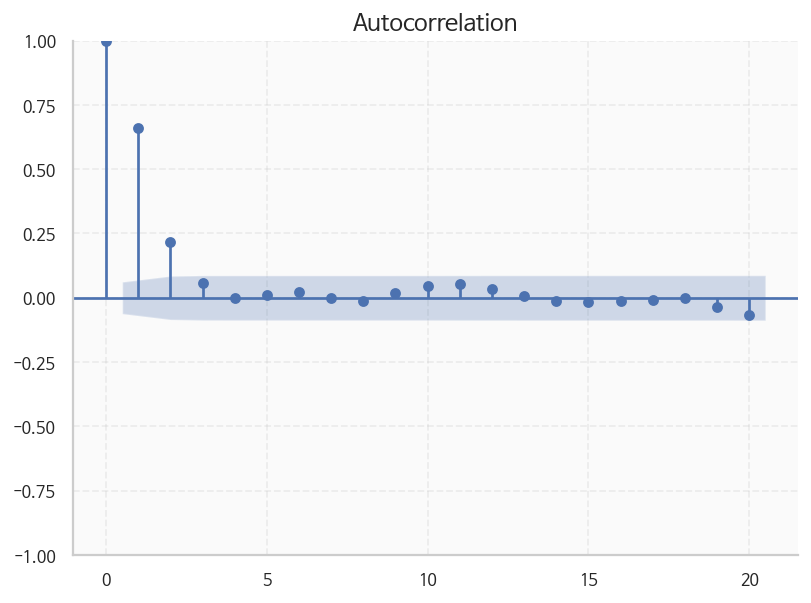

In [ ]:
# 코드

## 편자기상관관계
- 사인 곡선 패턴
- 차수 p의 값을 유추할 수 없음
- ARMA(1, 1) 프로세스 시뮬레이션한 데이터이지만 지연 1을 지난 후에도 계수가 유의함.
- PACF로도 차수 확인 불가

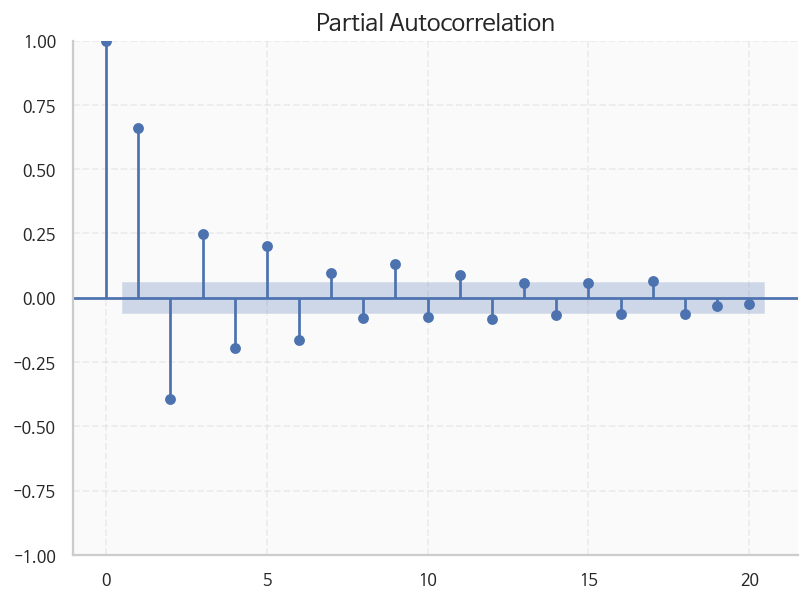

In [ ]:
# 코드

# AIC 활용한 모델 선택

In [ ]:
# 코드

[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]


## ARMA 모델 적합 위한 함수

In [ ]:
from typing import Union

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    """
    주어진 (p, q) 후보 리스트를 순회하며 가장 낮은 AIC를 가진 최적 모델을 찾음

    Args:
        endog: 분석할 시계열 데이터 (내생 변수)
        order_list: 탐색할 (p, q) 튜플들의 리스트 (예: [(1,1), (1,2), (2,1)...])
    """
    # 코드

    # AIC 기준 오름차순 정렬 (가장 우수한 모델이 맨 위로 오게 함)
    # lower AIC is better (낮은 AIC가 더 나은 모델)
    # 코드

    return result_df

In [ ]:
# 코드

100%|██████████| 16/16 [00:08<00:00,  1.80it/s]


,"(p,q)",AIC
0,"(1, 1)",2801.407785
1,"(2, 1)",2802.906070
2,"(1, 2)",2802.967762
3,"(0, 3)",2803.666793
4,"(1, 3)",2804.524027
5,"(3, 1)",2804.588567
6,"(2, 2)",2804.822282
7,"(3, 3)",2806.151032
8,"(2, 3)",2806.175380
9,"(3, 2)",2806.894930


# 잔차 분석


## 정성적 분석 : Q-Q 도식 확인

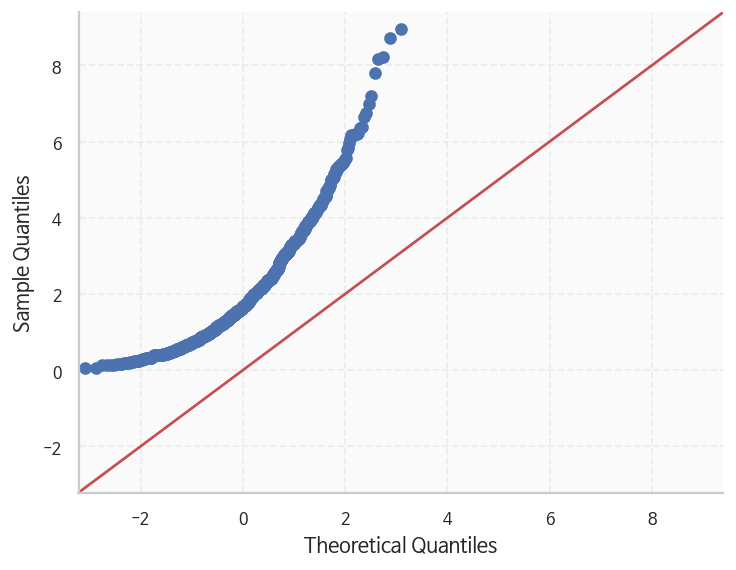

In [ ]:
from statsmodels.graphics.gofplots import qqplot

# 1. 비정규 분포 데이터 생성 (감마 분포)
# shape=2: 분포의 모양 결정 (작을수록 왼쪽으로 치우침)
# size=1000: 1000개의 샘플 데이터 생성
# 감마 분포는 비대칭(Skewed) 분포이므로 정규분포와는 다른 형태를 보입니다.
gamma = np.random.default_rng().standard_gamma(shape=2, size=1000)

# 2. Q-Q Plot 시각화
# qqplot(): 데이터의 분위수(Quantile)와 이론적 정규분포의 분위수를 비교함
# line='45': 데이터가 정규분포를 완벽히 따른다면 위치해야 할 45도 기준선을 그림
qqplot(gamma, line='45');

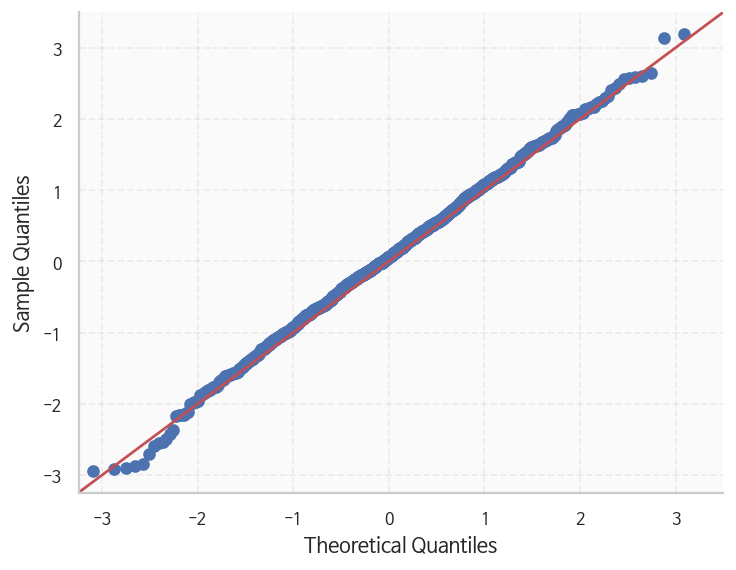

In [ ]:
# 코드

## 정량적 분석 : 융-박스 테스트

- **개념 (잔차 검정):**
  + 따라서 모델이 예측하고 남은 잔차(Residuals)에는 아무런 규칙이 없는 순수한 백색 잡음(White Noise)만 남아있어야 합니다.
  + 이를 통계적으로 확인하는 시험입니다.

- **가설 구조:**
  + **귀무가설 ($H_0$):** 잔차들 사이에 자기상관성이 없다. (즉, 순수한 백색 잡음이다)
  + **대립가설 ($H_1$):** 잔차들 사이에 자기상관성이 존재한다. (즉, 아직 못 찾은 패턴이 남아있다)


- **결과 해석 (p-value 기준):**
  + **$p$-value > 0.05 (통과):** 귀무가설을 기각하지 못합니다. 즉, 찌꺼기에 남은 패턴이 없으므로 "현재 모델이 데이터를 아주 잘 설명하고 있다(합격)"는 뜻입니다.
  + **$p$-value < 0.05 (재학습):** 귀무가설이 기각됩니다. 찌꺼기에 아직 우리가 놓친 패턴이 남아있으므로, "ARIMA 차수(p, q)를 바꾸거나 모델을 수정해야 한다(불합격)"는 뜻입니다.


- 결론적으로, 융-박스 검정을 돌렸을 때 모든 시차(Lag 1 ~ 10)에서 **$p$-value가 0.05보다 크게 나와야 안심하고 그 모델을 실무에 배포**할 수 있습니다!

## 잔차 분석 수행

In [ ]:
# 코드

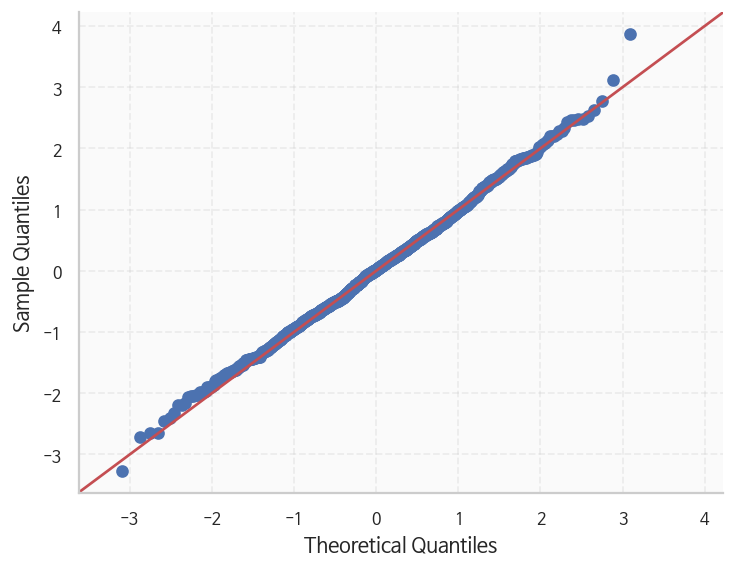

In [ ]:
# 코드

## 그래프 해석
- 왼쪽 상단 도식 : 전체 데이터 집합의 잔차
  + 특이한 추세 미 존재, 평균 시간이 지나도 안정적으로 백색소음과 같은 정상성
- 오른쪽 상단 도식 : 잔차의 히스토그램
  + 잔차가 백색소음에 가까움
- 오른쪽 하단 도식 : 잔차의 자기상관함수

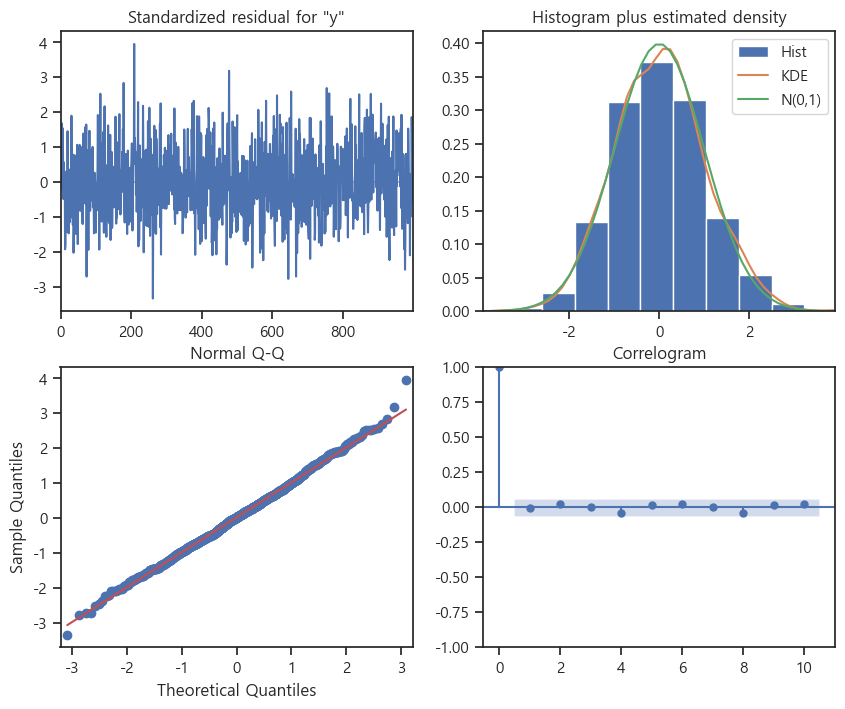

In [ ]:
# 코드

- **코드의 의미:** * `residuals`: 예측 모델을 통과하고 남은 실제 오차(찌꺼기) 데이터입니다.
- `np.arange(1, 11, 1)`: 시차(Lag) 1부터 10까지 묶어서, 찌꺼기들 사이에 혹시라도 자기상관성(패턴)이 남아있는지 전반적으로 검사하겠다는 뜻입니다.


In [ ]:
# 코드

,lb_stat,lb_pvalue
1,0.030706,0.860897
2,0.528021,0.767966
3,0.540904,0.909817
4,2.079774,0.721089
5,2.271897,0.810385
6,2.896262,0.821750
7,2.900378,0.894063
8,4.418799,0.817501
9,4.787567,0.852419
10,5.246805,0.874093


# 대역폭 데이터 활용, 일반적 모델링 절차

## 데이터 불러오기
- 어떤 IT 기업이나 웹 서비스의 서버 네트워크 대역폭(트래픽) 사용량을 1시간(Hourly) 단위로 기록한 데이터입니다. (단위: MBps)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/ts_data/'

df = pd.read_csv(DATA_PATH + 'bandwidth.csv')
df.head()

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019
3,1004.702118
4,1007.447816


## 시각화


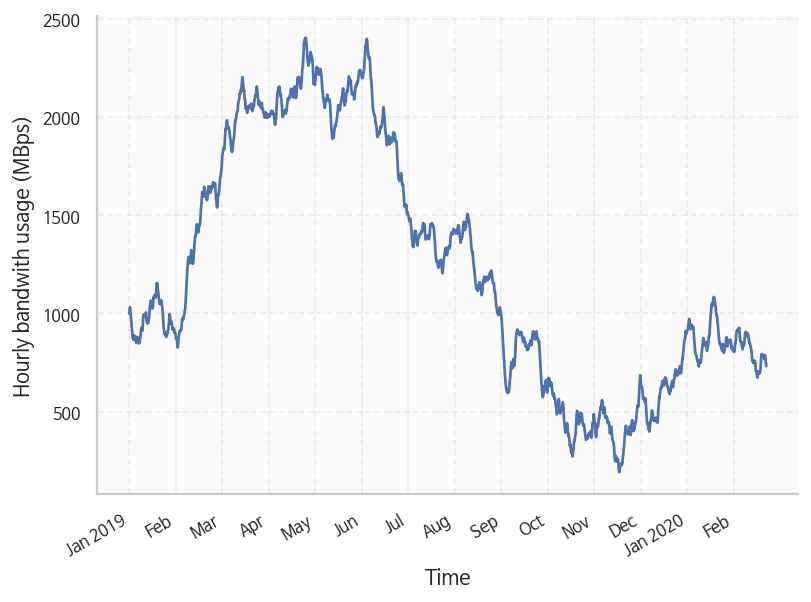

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(df['hourly_bandwidth'])
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

plt.xticks(
    np.arange(0, 10000, 730),
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## ADF 테스트
- 귀무가설 : 시계열이 비정상적이다.
- 대립가설 : 시계열이 정상적이다.

In [ ]:
# 코드

ADF Statistic: -0.8714653199452735
p-value: 0.7972240255014551


- 1차 차분

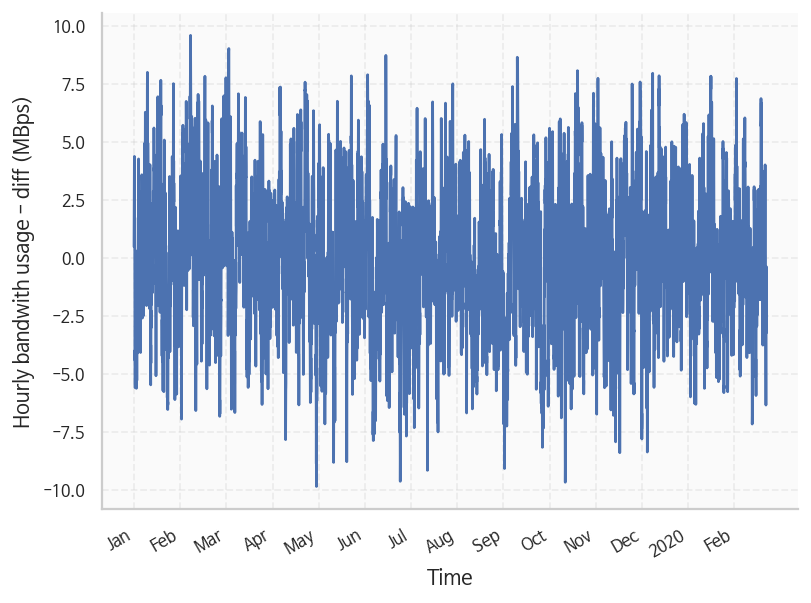

In [ ]:
import matplotlib.pyplot as plt

bandwidth_diff = np.diff(df.hourly_bandwidth, n=1)

fig, ax = plt.subplots()

ax.plot(bandwidth_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage - diff (MBps)')

plt.xticks(
    np.arange(0, 10000, 730),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# 코드

ADF Statistic: -20.694853863789017
p-value: 0.0


## ACF와 PACF 그래프
- ACF의 패턴: 천천히 지수적으로 감소 (Slow/Exponential Decay)
  + 이동평균 모델 적용 불가 MA(q) 차수

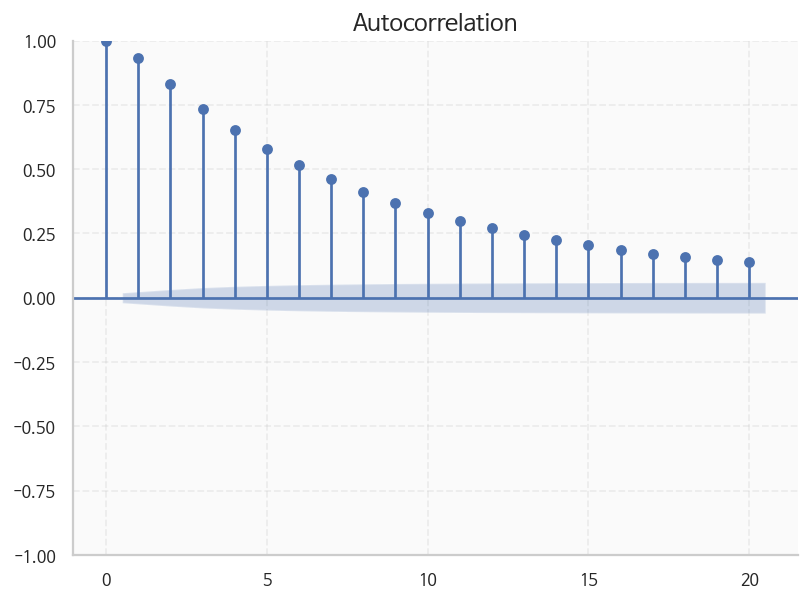

In [ ]:
# 코드

- PACF의 패턴: 특정 시차(Lag 2) 이후 급격히 단절 (Cut-off)
  + AR 모델 적용 가능?
- Lag 1 (첫 번째 막대) : 약 0.9 근처로 파란색 신뢰구간을 크게 뚫고 솟아 있습니다. 1시간 전의 트래픽이 현재 트래픽에 매우 강한 긍정적(+) 영향을 미친다는 뜻입니다.
- Lag 2 (두 번째 막대) : 아래로 뻗어 파란색 신뢰구간을 뚫고 나왔습니다(유의미함). 2시간 전의 트래픽도 현재 트래픽에 직접적인 영향을 미치고 있음을 의미합니다.
- 사인 곡선 이룬듯한 패턴 보임. 그러면 차수 결정 어려움

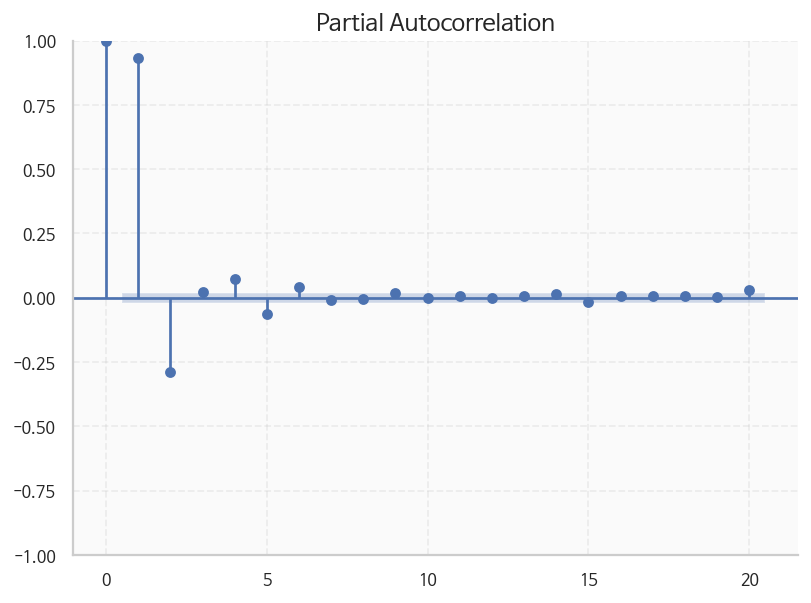

In [ ]:
# 코드

## MA? AR? 정리

- 시계열 모델을 설계할 때 ACF와 PACF 그래프는 서로 짝을 이루어 '어떤 모형(AR vs MA)을 사용할 것인가'와 '몇 차수(p, q)를 적용할 것인가'를 결정하는 나침반 역할을 합니다.

### 1. 이동평균 모형 (MA: Moving Average) 적용 관점

- MA 모형은 과거 데이터의 '오차(Error)'가 현재에 미치는 영향을 모델링합니다.
- 이 모형을 적용하려면 **ACF 그래프**를 중점적으로 확인해야 합니다.
- **판별 기준:** MA 모형에 적합한 데이터는 ACF 그래프가 특정 시차(q)까지만 유의미하게 나타나고, 그 이후로는 0으로 급격히 떨어지는 **단절(Cut-off)** 패턴을 보입니다.
  + **현재 그래프 해석:** 확인하신 ACF 그래프는 뚝 끊기는 구간 없이 시차 20까지 계단식으로 아주 천천히 감소(Tailing off)하고 있습니다.
  + **결론:** 과거의 오차가 일시적으로 충격을 주고 사라지는 형태가 아니므로 이 데이터는 MA 모형으로 설명하기 부적합합니다. 따라서 MA 차수는 **q=0**으로 결정됩니다.

---

### 2. 자기회귀 모형 (AR: Autoregressive) 적용 관점

- AR 모형은 과거의 '관측된 데이터 값' 자체가 현재 데이터에 미치는 영향을 모델링합니다. 이 모형을 적용하려면 **PACF 그래프**를 중점적으로 확인해야 합니다.
- **판별 기준:** AR 모형에 적합한 데이터는 ACF가 천천히 감소하는 반면, PACF 그래프는 특정 시차(p)까지만 유의미한 값을 가지고 그 이후로는 신뢰구간 안으로 떨어지는 **단절(Cut-off)** 패턴을 보입니다.
  + **현재 그래프 해석:** 확인하신 PACF 그래프는 시차 1과 2에서만 파란색 신뢰구간을 뚫고 나와 강한 상관성을 보였으며, 시차 3부터는 완벽하게 0 부근으로 단절되었습니다.
  + **결론:** 이는 "정확히 2시간 전까지의 트래픽 트렌드만이 현재의 트래픽을 결정하는 직접적인 원인이다"라는 강력한 통계적 증거입니다. 따라서 이 데이터는 AR 모형을 적용하기에 완벽한 조건을 갖추고 있으며, AR 차수는 **p=2**로 결정됩니다.

---

### 요약: 박스-젠킨스(Box-Jenkins) 모델 판별 표

- 이러한 패턴 분석을 통계학에서는 박스-젠킨스 방법론이라고 합니다. 현재 데이터의 상태를 표로 요약하면 다음과 같습니다.

| 분석 관점 | ACF 그래프 패턴 | PACF 그래프 패턴 | 모델 채택 결과 |
| --- | --- | --- | --- |
| **AR(p) 모형** | 천천히 감소 (Tailing off) | **특정 시차 이후 단절 (Cut-off)** | **채택 (p=2)** |
| **MA(q) 모형** | 특정 시차 이후 단절 (Cut-off) | 천천히 감소 (Tailing off) | 기각 (q=0) |

- 따라서 1차 차분(d=1)을 통해 정상성을 만든 이 대역폭 데이터는 최종적으로 **ARIMA(2, 1, 0)** 모형을 적용하는 것이 가장 과학적이고 타당한 접근법입니다.

## 훈련집합 및 테스트 집합 시각화

In [ ]:
# 코드

9831
168


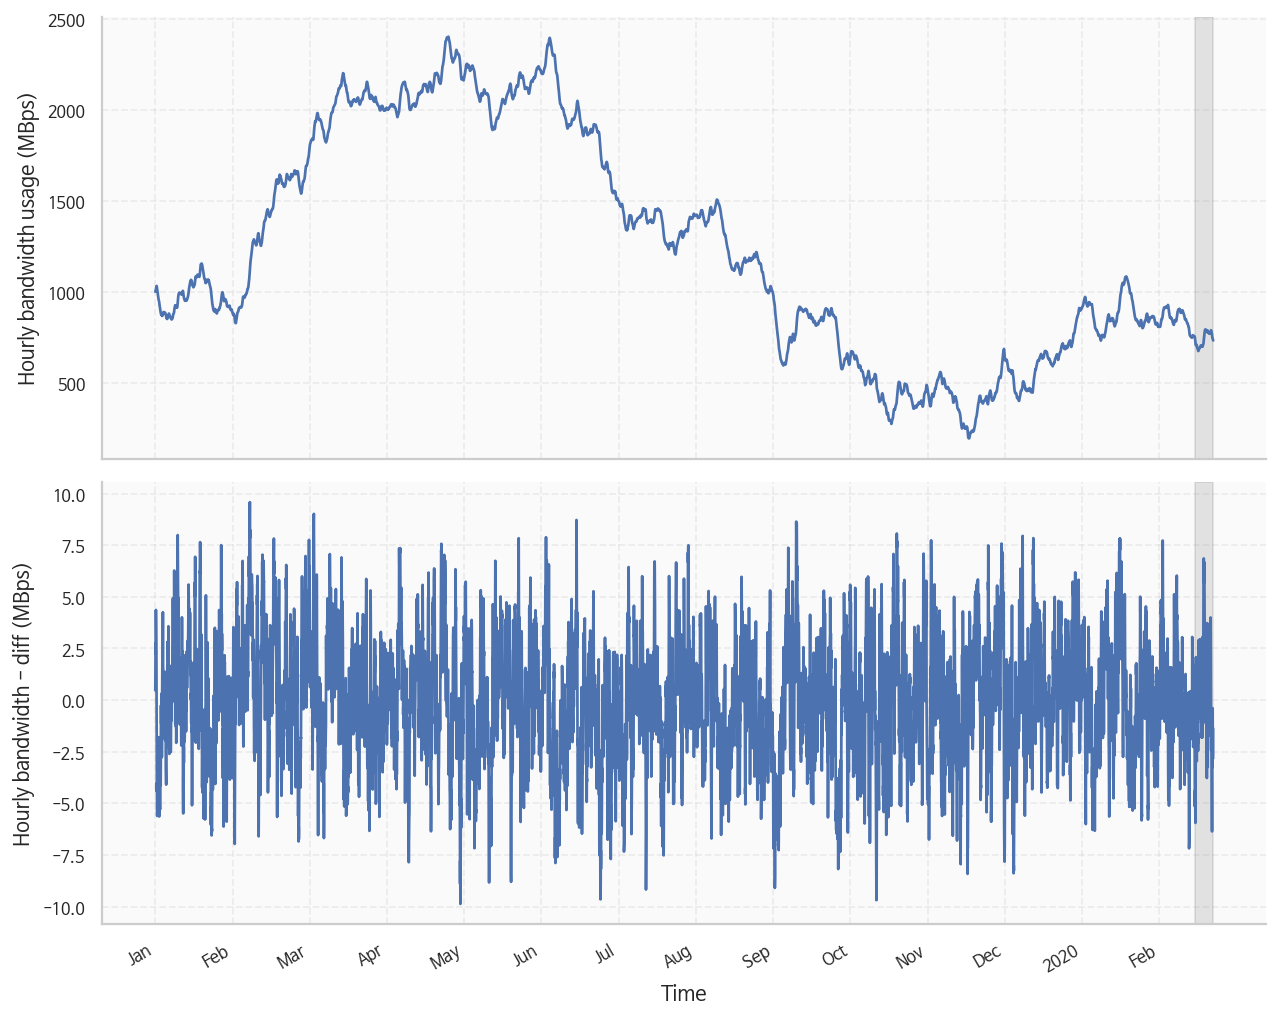

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))

ax1.plot(df['hourly_bandwidth'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Hourly bandwidth usage (MBps)')
ax1.axvspan(9831, 10000, color='#808080', alpha=0.2)

ax2.plot(df_diff['bandwidth_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Hourly bandwidth - diff (MBps)')
ax2.axvspan(9830, 9999, color='#808080', alpha=0.2)

plt.xticks(
    np.arange(0, 10000, 730),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## ARMA 모델 피팅
- 핵심 개념: AIC (Akaike Information Criterion)
  + 정의: 모델이 데이터를 얼마나 잘 설명하는지(Likelihood)와 모델에 사용된 파라미터 수(Complexity)를 종합적으로 평가하는 지표입니다.
  + 원리: 파라미터가 너무 많아지면 모델이 복잡해져서 벌점(Penalty)을 부여합니다. 즉, "최소한의 파라미터로 최대한의 설명력을 가진 모델"을 찾도록 유도합니다.
  + 해석: 출력된 데이터프레임의 가장 첫 번째 행(AIC가 가장 낮은 행)에 있는 (p, q) 조합이 현재 데이터에 가장 적합한 ARMA 모델의 차수입니다.

In [1]:
# 코드

NameError: name 'pd' is not defined

In [ ]:
# 코드

100%|██████████| 16/16 [00:39<00:00,  2.47s/it]


,"(p,q)",AIC
0,"(3, 2)",27991.063879
1,"(2, 3)",27991.287509
2,"(2, 2)",27991.603598
3,"(3, 3)",27993.416924
4,"(1, 3)",28003.349550
5,"(1, 2)",28051.351401
6,"(3, 1)",28071.155496
7,"(3, 0)",28095.618186
8,"(2, 1)",28097.250766
9,"(2, 0)",28098.407664


## 잔차 분석
- summary() 결과에서 반드시 확인해야 할 3가지
  + coef (계수): 각 AR(p)와 MA(q) 성분이 현재 값에 미치는 영향력의 크기입니다.
  + P>|z| (P-value): 각 계수가 통계적으로 유의미한지 확인합니다. 보통 0.05보다 작아야 해당 파라미터가 모델에 실질적인 도움을 준다고 판단합니다.
  + Ljung-Box (L1) / Jarque-Bera (JB):
    - Ljung-Box: 잔차에 아직 자기상관이 남아있는지 테스트합니다. (유의확률이 커야 좋음)
    - Jarque-Bera: 잔차가 정규분포를 따르는지 테스트합니다. (유의확률이 커야 좋음)

In [ ]:
# 코드

                               SARIMAX Results                                
Dep. Variable:         bandwidth_diff   No. Observations:                 9831
Model:               SARIMAX(3, 1, 2)   Log Likelihood              -14030.847
Date:                Sun, 05 Jul 2026   AIC                          28073.694
Time:                        06:05:36   BIC                          28116.853
Sample:                             0   HQIC                         28088.315
                               - 9831                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3531      0.051      6.978      0.000       0.254       0.452
ar.L2          0.7566      0.056     13.561      0.000       0.647       0.866
ar.L3         -0.2720      0.014    -19.449      0.0

### 잔차 진단 4종 해석

- **1. Standardized residual (좌측 상단):**
  + **해석:** 시간이 흐름에 따라 잔차의 변동을 보여주는 시계열 그래프입니다.
  + **상태:** 데이터가 특정 방향으로 튀지 않고 평균 0을 중심으로 위아래로 고르게 진동하고 있습니다. 분산도 일정해 보이므로 **정상성(Stationary) 조건을 만족**합니다.


- **2. Histogram plus estimated density (우측 상단):**
  + **해석:** 잔차의 분포가 정규분포를 따르는지 확인하는 그래프입니다. 주황색 선(KDE: 실제 데이터 분포)과 초록색 선(N(0,1): 이론적인 표준정규분포)이 얼마나 겹치는지 봅니다.
  + **상태:** 두 선이 완벽하게 포개어집니다. 즉, 모델이 예측하지 못한 오차들은 순수한 무작위 노이즈인 **정규분포를 따르고 있음**을 뜻합니다.


- **3. Normal Q-Q (좌측 하단):**
  + **해석:** 정규성을 시각적으로 재확인하는 그래프입니다. 파란색 점들이 빨간색 직선 위에 예쁘게 올라타 있을수록 정규분포에 가깝습니다.
  + **상태:** 양 끝단에서 아주 미세한 이탈을 제외하면 **대부분의 점이 빨간 선 위에 완벽히 정렬**되어 있어 정규성 가정이 훌륭하게 성립합니다.


- **4. Correlogram (우측 하단):**
  + **해석:** **이 부분이 핵심입니다.** 잔차의 ACF 그래프입니다.
  + **상태:** 시차 0(Lag 0)을 제외한 **모든 시차(1~10)의 막대들이 파란색 음영 영역(신뢰구간) 안**에 아주 얌전하게 갇혀 있습니다. 즉, 잔차들 사이에 유의미한 자기상관성이 남아있지 않습니다.




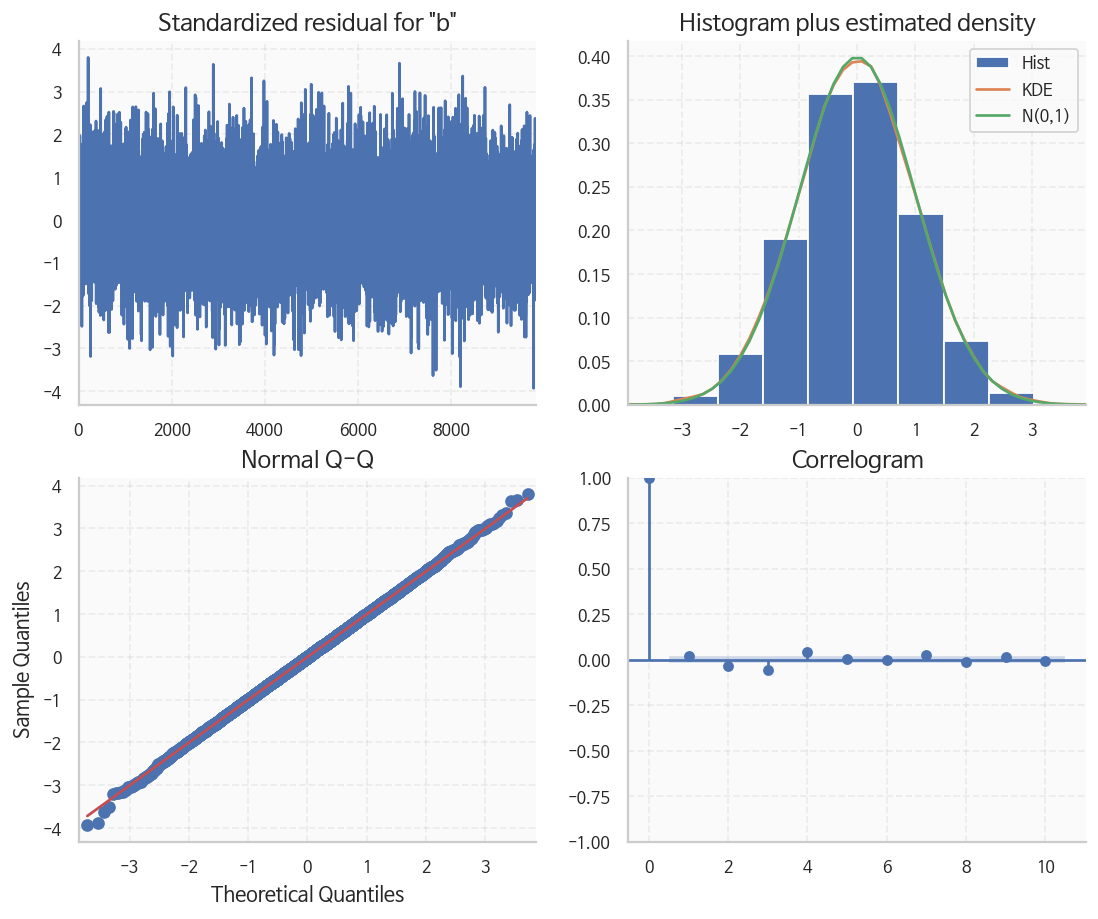

In [ ]:
# 코드

### 융-박스 결과 해석

- 비즈니스 대역폭 데이터(bandwidth)의 숨겨진 정체는 바로 주기성(Seasonality)입니다.
- 데이터가 'Hourly(1시간 단위)'로 집계된 네트워크 트래픽 데이터
- 현실 세계의 네트워크 트래픽은 매일 비슷한 시간에 튀는 24시간 주기(Daily Seasonality)를 가질 확률이 매우 높음.
- 융-박스 검정이 잡아낸 패턴:
  + 일반 ARMA 모델은 '24시간 전', '48시간 전' 같은 장기적인 하루 단위 주기성을 전혀 학습하지 못합니다.


In [ ]:
# 코드

,lb_stat,lb_pvalue
1,3.045506,8.096090e-02
2,13.786906,1.014405e-03
3,45.137730,8.649616e-10
4,64.204861,3.784003e-13
5,64.538522,1.397051e-12
6,64.542734,5.348435e-12
7,71.432543,7.582276e-13
8,72.880181,1.309405e-12
9,75.292885,1.383250e-12
10,75.873094,3.216335e-12


### 융-박스 결과와의 모순? 완벽한 미스터리 해결!

- 여기서 아주 재미있는 통계적 현상이 발생합니다.
- "융-박스 검정 테이블에서는 Lag 2부터 p-value가 0에 가깝게 나와서 '불합격(패턴이 남아있음)'
  + 그 이유는 데이터 개수(No. Observations = 9831)가 너무 많기 때문입니다.
샘플 사이즈가 수천, 수만 개로 커지면 통계적 검정(융-박스 검정)은 **아주 미세하고 인간이 무시해도 될 수준의 작은 상관성조차 모두 잡아내어 p-value를 0으로(불합격으로) 떨어뜨리는 경향**이 있습니다.
  + 이를 통계학에서는 '과도한 검정력(Excessive Power)'의 문제.

## 대역폭 사용량 예측하기

In [ ]:
# 코드

In [ ]:
# 코드

In [ ]:
fig, ax = plt.subplots()

ax.plot(df_diff['bandwidth_diff'])
ax.plot(test['bandwidth_diff'], 'b-', label='actual')
ax.plot(test['pred_mean'], 'g:', label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_ARMA'], 'k--', label='ARMA(2,2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwidth - diff (MBps)')

ax.axvspan(9830, 9999, color='#808080', alpha=0.2)

ax.set_xlim(9800, 9999)

plt.xticks(
    [9802, 9850, 9898, 9946, 9994],
    ['2020-02-13', '2020-02-15', '2020-02-17', '2020-02-19', '2020-02-21'])

fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# 코드

In [ ]:
# 코드

# ARIMA : 비정상 시계열

In [ ]:
# 1. 성능 평가 지표 (실제값과 예측값의 차이 계산)
from sklearn.metrics import mean_squared_error, mean_absolute_error # MSE, MAE 계산

# 2. 시계열 패턴 분석 및 시각화
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf      # 자기상관(ACF) 및 부분자기상관(PACF) 도식화

# 3. 통계적 사후 검정
from statsmodels.stats.diagnostic import acorr_ljungbox           # 융-박스 검정 (잔차에 정보가 남았는지 확인)
from statsmodels.graphics.gofplots import qqplot                  # Q-Q Plot (잔차의 정규성 확인)

# 4. 시계열 모델링 및 데이터 생성
from statsmodels.tsa.statespace.sarimax import SARIMAX             # (S)ARIMA(X) 모델 구축 핵심 도구
from statsmodels.tsa.arima_process import ArmaProcess              # 이론적 계수를 활용한 가상 시계열 생성
from statsmodels.tsa.stattools import adfuller                     # ADF 검정 (데이터의 정상성/안정성 판별)

# 5. 최적화 및 편의 도구
from tqdm import tqdm_notebook                                     # 주피터 노트북용 진행률 표시바
from itertools import product                                      # 파라미터 조합(Grid Search) 생성용
from typing import Union                                           # 파이썬 타입 힌트 설정용

# 6. 데이터 분석 및 시각화 기본 라이브러리
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 7. 경고 제어 및 인라인 출력 설정
import warnings
warnings.filterwarnings('ignore') # 분석에 지장이 없는 단순 경고 메시지 숨김
# %matplotlib inline                # 생성된 그래프를 노트북 결과창에 바로 표시

## 데이터 수집

In [ ]:
df = pd.read_csv(DATA_PATH + 'jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


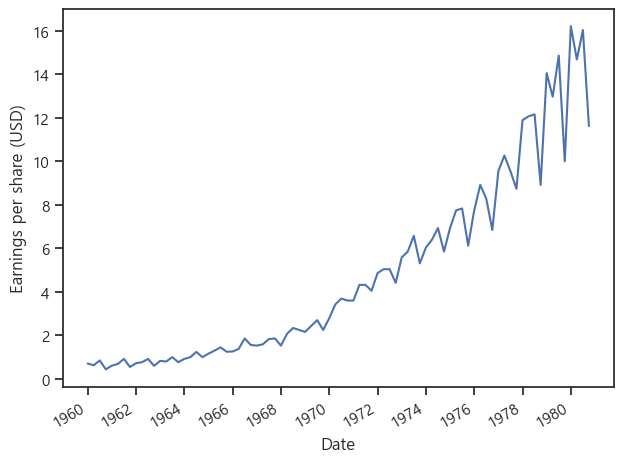

In [ ]:
fig, ax = plt.subplots()

ax.plot(df.date, df['data'])
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## 단위근 검정
- 차분 2회 지정

In [ ]:
ad_fuller_result = adfuller(df['data'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 2.7420165734574735
p-value: 1.0


In [ ]:
eps_diff = np.diff(df['data'], n=1)

ad_fuller_result = adfuller(eps_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -0.40740976363804116
p-value: 0.9088542416911313


In [ ]:
eps_diff2 = np.diff(eps_diff, n=1)

ad_fuller_result = adfuller(eps_diff2)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -3.585162874793187
p-value: 0.006051099869603033


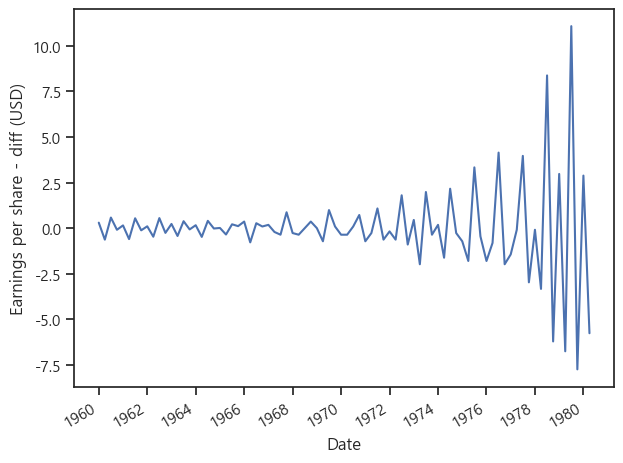

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['date'][2:], eps_diff2)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share - diff (USD)')

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

## 예측 구간 설정

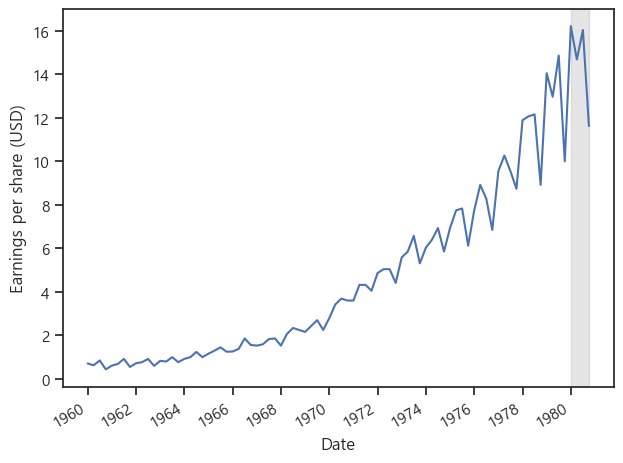

In [ ]:
fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

## ARIMA 최적화

In [ ]:
from typing import Union

def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:
    """
    주어진 차분 횟수(d) 하에서 (p, q) 후보 리스트를 순회하며 최적의 AIC 모델을 탐색함

    Args:
        endog: 분석할 시계열 데이터
        order_list: 탐색할 (p, q) 조합 리스트 (예: [(0,1), (1,1), ...])
        d: 통합(Integrated) 차수, 즉 정상성을 만들기 위한 차분 횟수
    """
    results = []

    # 1. tqdm_notebook을 사용하여 주피터 노트북 환경에서 진행 바 표시
    for order in tqdm_notebook(order_list):
        try:
            # 2. SARIMAX 모델 설정 및 학습
            # order=(p, d, q): 전달받은 d를 고정하고 p와 q를 변화시키며 학습
            # simple_differencing=False: 더 정밀한 로그 우도(Log-likelihood) 계산 방식 사용
            model = SARIMAX(endog, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            # 수렴 실패나 수학적 오류가 발생하는 특정 조합은 무시하고 다음으로 진행
            continue

        # 3. 모델의 적합도(AIC) 수집
        aic = model.aic
        results.append([order, aic])

    # 4. 수집된 [조합, AIC] 데이터를 데이터프레임으로 변환
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']

    # 5. AIC 기준 오름차순 정렬 (Lower AIC is better)
    # 가장 효율적인(성능 대비 파라미터가 적은) 모델이 상단에 위치함
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

- 조합 목록

In [ ]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
d = 2

order_list = list(product(ps, qs))

- 조합 목록 결과

In [ ]:
train = df['data'][:-4]

result_df = optimize_ARIMA(train, order_list, d)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",AIC
0,"(3, 3)",115.272663
1,"(3, 1)",115.624981
2,"(3, 2)",115.672008
3,"(3, 0)",154.430621
4,"(0, 3)",194.654716
5,"(0, 2)",209.274731
6,"(2, 3)",220.666967
7,"(1, 3)",228.267808
8,"(1, 2)",228.935808
9,"(2, 2)",229.974679


## ARIMA 모델 적용

In [ ]:
model = SARIMAX(train, order=(3,2,3), simple_differencing=False)
model_fit = model.fit(disp=False)

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   data   No. Observations:                   80
Model:               SARIMAX(3, 2, 3)   Log Likelihood                 -50.636
Date:                Fri, 03 Apr 2026   AIC                            115.273
Time:                        14:02:36   BIC                            131.770
Sample:                             0   HQIC                           121.877
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9985      0.037    -26.646      0.000      -1.072      -0.925
ar.L2         -0.9867      0.040    -24.675      0.000      -1.065      -0.908
ar.L3         -0.9751      0.026    -36.849      0.0

## 모델 결과 확인
- 왼쪽 상단 : 시간에 따른 잔차
  + 분산이 일정하지 않음, 백색 소음과 차이 존재
- 오른쪽 상단 : 잔차의 분포, 정규분포에 가까움
- Q-Q 도식 : 직선적인 선 표시
- 상관관계도 : 지연 3에서 계수가 유의함
- 모델의 오차가 무작위적

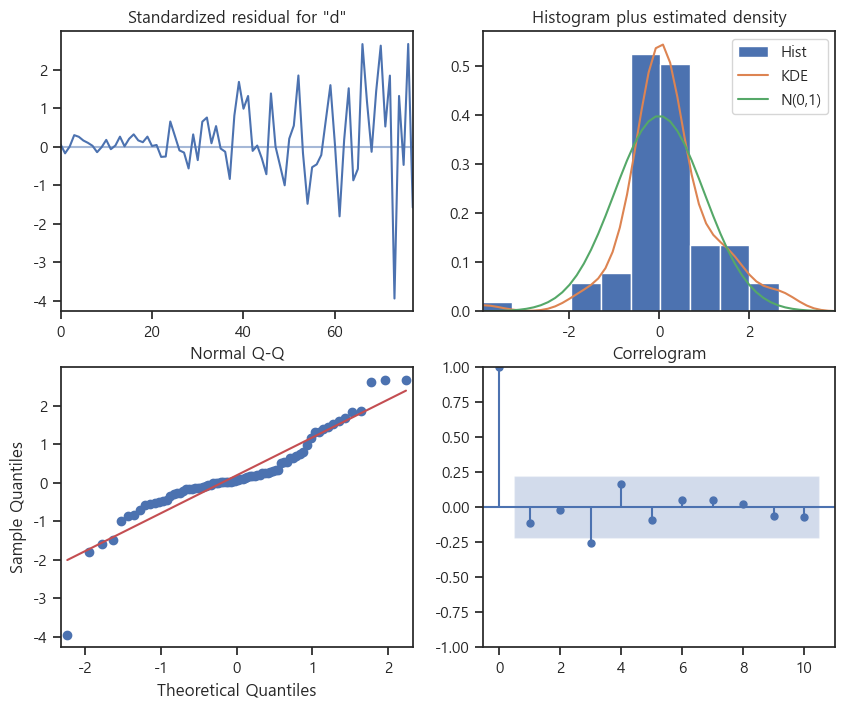

In [ ]:
model_fit.plot_diagnostics(figsize=(10,8));

- 정량적 관점 테스트
  + 모두 p값이 0.05보다 큼, 귀무가설 기각하지 않고, 백색소음과 마찬가지로 상관관계 없음

In [ ]:
# 잔차(residuals) 추출
residuals = model_fit.resid
# Ljung-Box 검정으로 잔차의 자기상관 확인 (1~10구간)
acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,1.668060,0.196519
2,1.668764,0.434143
3,7.315256,0.062500
4,9.291318,0.054216
5,9.919501,0.077549
6,10.145511,0.118656
7,10.392329,0.167409
8,10.428801,0.236209
9,10.773760,0.291536
10,11.227228,0.340091


## 테스트

In [ ]:
test = df.iloc[-4:]

test['naive_seasonal'] = df['data'].iloc[76:80].values
test

,date,data,naive_seasonal
80,1980-01-01,16.20,14.04
81,1980-04-01,14.67,12.96
82,1980-07-02,16.02,14.85
83,1980-10-01,11.61,9.99


In [ ]:
ARIMA_pred = model_fit.get_prediction(80, 83).predicted_mean

test['ARIMA_pred'] = ARIMA_pred
test

,date,data,naive_seasonal,ARIMA_pred
80,1980-01-01,16.20,14.04,15.855507
81,1980-04-01,14.67,12.96,14.380541
82,1980-07-02,16.02,14.85,16.369692
83,1980-10-01,11.61,9.99,11.684409


- 파선으로 표시된 ARIMA(3, 2, 3) 모델의 예측이 1980년에 관측된 데이터와 거의 완벽하게 겹치는 것 확인

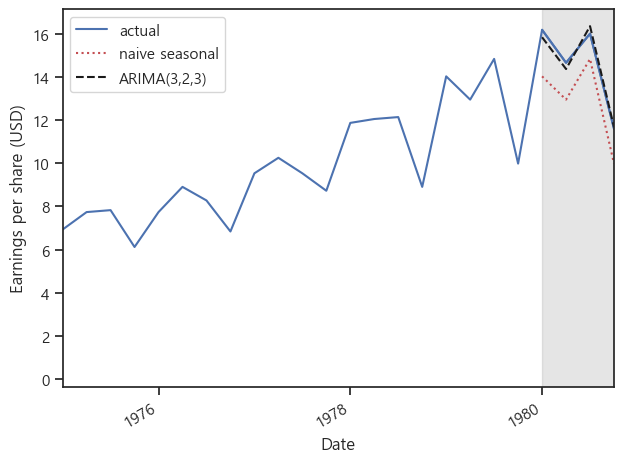

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['date'], df['data'])
ax.plot(test['data'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(3,2,3)')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
ax.set_xlim(60, 83)

fig.autofmt_xdate()
plt.tight_layout()

## 기존 모델과 결과 비교

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_naive_seasonal = mape(test['data'], test['naive_seasonal'])
mape_ARIMA = mape(test['data'], test['ARIMA_pred'])

print(mape_naive_seasonal, mape_ARIMA)

11.561658552433654 1.7308473667949693


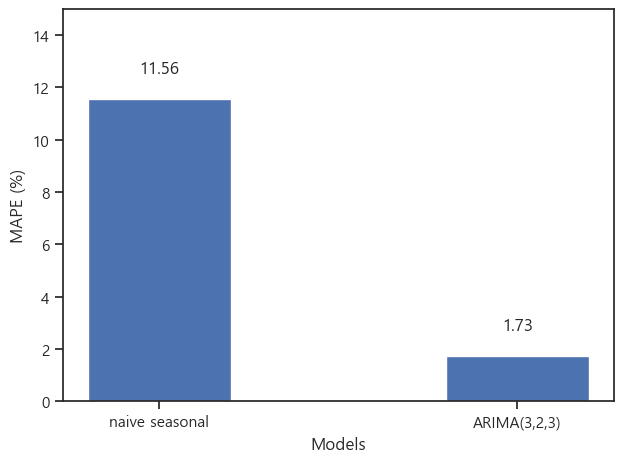

In [ ]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(3,2,3)']
y = [mape_naive_seasonal, mape_ARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()

# SARIMA (계절성 고려)
- 계절적 자기회귀누적이동평균 모델

In [ ]:
# 1. 모델 성능 평가 지표
from sklearn.metrics import mean_squared_error, mean_absolute_error # MSE, MAE 오차 계산

# 2. 시계열 패턴 및 자기상관 분석
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf      # ACF(자기상관), PACF(부분자기상관) 시각화

# 3. 시계열 분해 (Decomposition)
# seasonal_decompose: 고전적 시계열 분해 (추세 + 계절성 + 잔차)
# STL: Loess를 이용한 계절성-추세 분해 (최신 기법으로 더 유연함)
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# 4. 통계적 검정 및 진단
from statsmodels.stats.diagnostic import acorr_ljungbox           # 융-박스 검정 (잔차의 독립성/백색잡음 여부 확인)
from statsmodels.graphics.gofplots import qqplot                  # Q-Q Plot (잔차의 정규성 시각화)
from statsmodels.tsa.stattools import adfuller                     # ADF 검정 (데이터의 정상성/안정성 판별)

# 5. 시계열 모델링 및 프로세스 생성
from statsmodels.tsa.statespace.sarimax import SARIMAX             # (S)ARIMA(X) 모델 구축 핵심 도구
from statsmodels.tsa.arima_process import ArmaProcess              # 이론적 계수를 바탕으로 가상 시계열 생성

# 6. 최적화 및 편의 도구
from tqdm import tqdm_notebook                                     # 주피터 노트북용 진행률 표시바
from itertools import product                                      # 파라미터 조합(Grid Search) 생성용
from typing import Union                                           # 파이썬 타입 힌트 설정용

# 7. 데이터 처리 및 시각화 기본 라이브러리
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 8. 환경 설정
import warnings
warnings.filterwarnings('ignore') # 분석에 지장이 없는 단순 경고 메시지 숨김
# %matplotlib inline                # 생성된 그래프를 노트북 결과창에 바로 표시

## 데이터 가져오기

In [ ]:
df = pd.read_csv(DATA_PATH + 'air-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


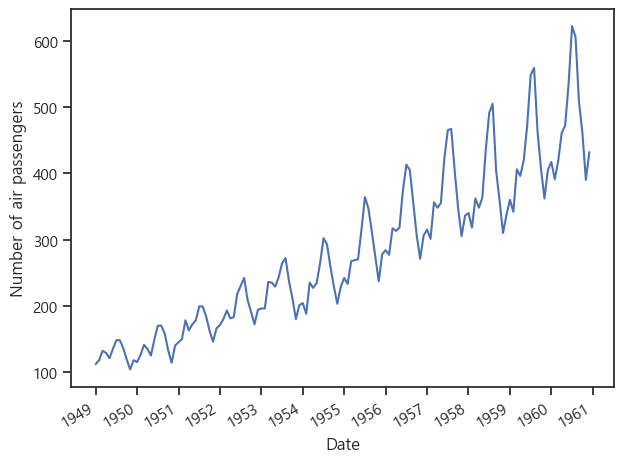

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## 계절성 데이터 확인

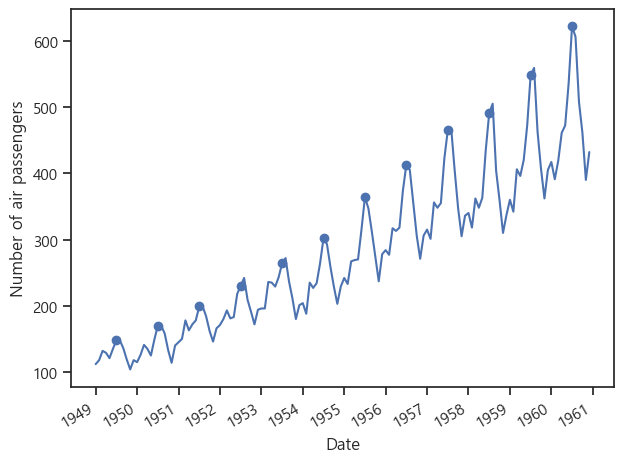

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'], markevery=np.arange(6, 145, 12), marker='o')
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 계절별 패턴 패턴

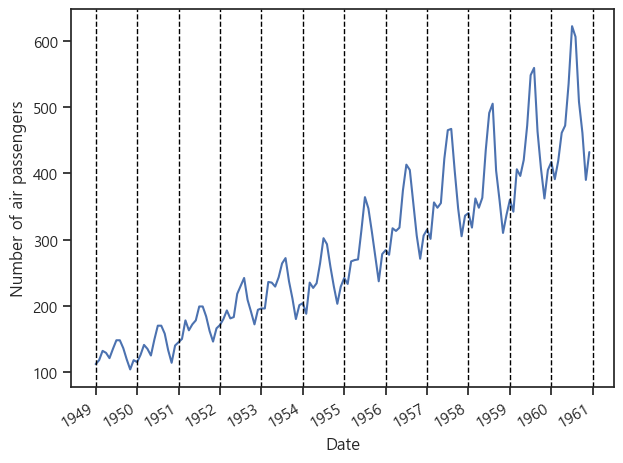

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
for i in np.arange(0, 145, 12):
    ax.axvline(x=i, linestyle='--', color='black', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## 시계열 분해

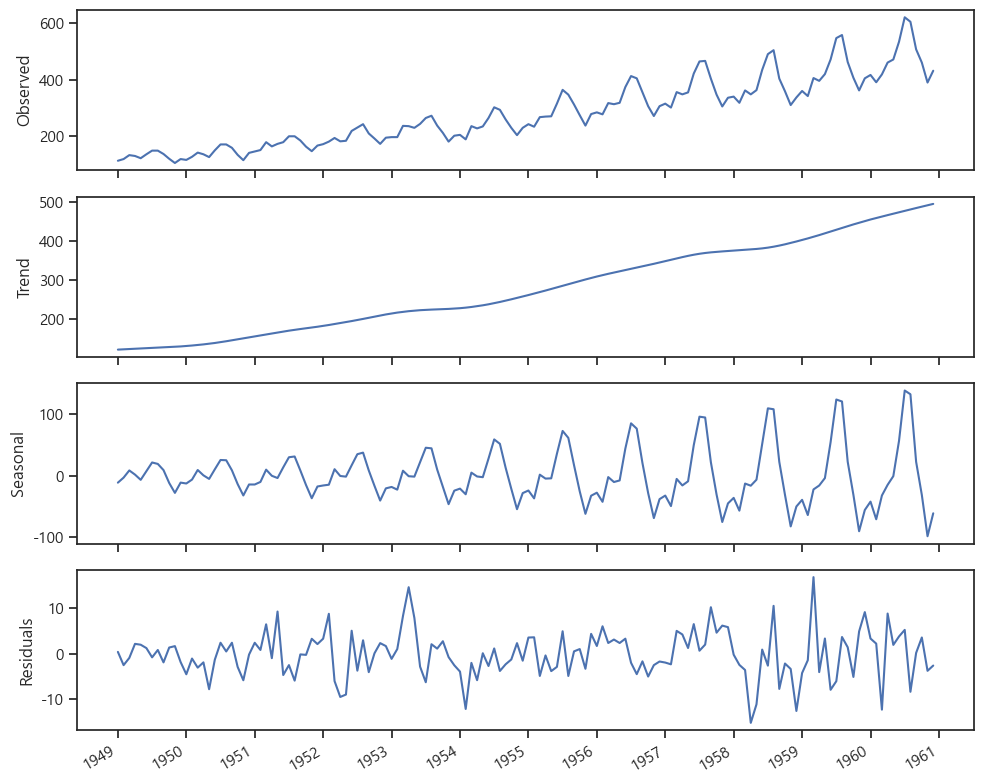

In [ ]:
decomposition = STL(df['Passengers'], period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 계절성 시계열이 없는 그래프

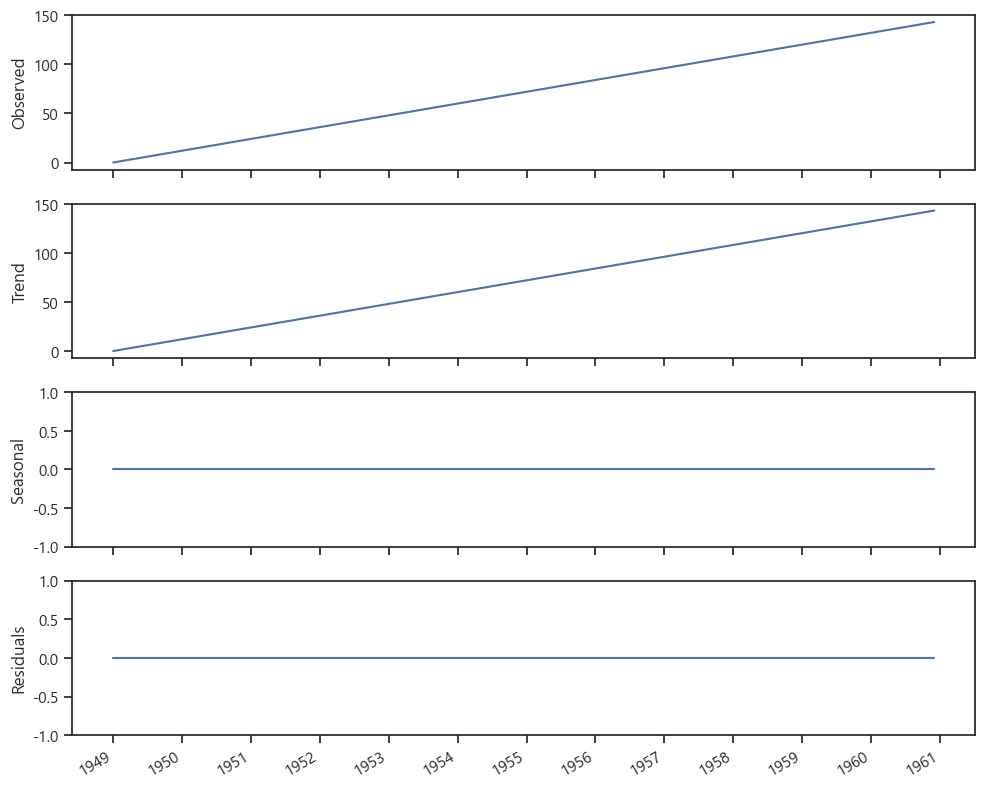

In [ ]:
linear_ts = np.arange(0, 144, 1)

decomposition = STL(linear_ts, period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax3.set_ylim(-1, 1)

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
ax4.set_ylim(-1, 1)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## ADF 테스트

In [ ]:
ad_fuller_result = adfuller(df['Passengers'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


- 두번 차분 진행

In [ ]:
df_diff = np.diff(df['Passengers'], n=1)

ad_fuller_result = adfuller(df_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.8292668241699994
p-value: 0.0542132902838255


In [ ]:
df_diff_seasonal_diff = np.diff(df_diff, n=12)

ad_fuller_result = adfuller(df_diff_seasonal_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -17.62486236018866
p-value: 3.823046855895306e-30


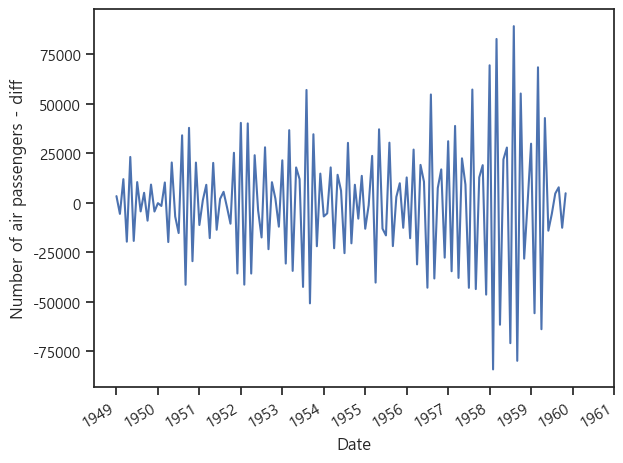

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['Month'][13:], df_diff_seasonal_diff)
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers - diff')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 예측 구간 설정

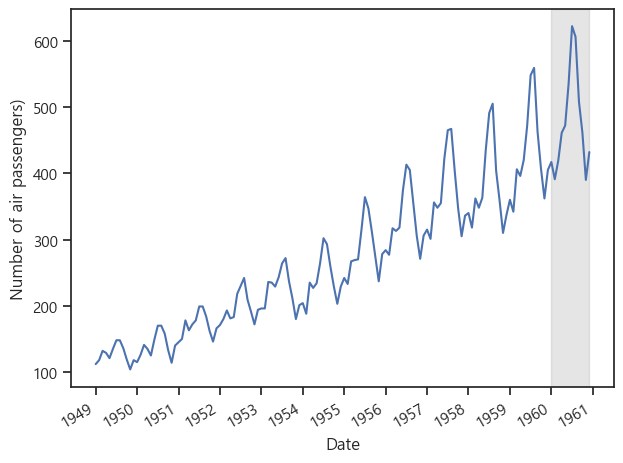

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers)')
ax.axvspan(132, 143, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## ARIMA 모델 적합
- d = 2
- p와 q 차수 구하기
  + 0에서 12사이의 값 적용 (데이터 매월 측정, 계절적 요인 있음 확인)
- 최상의 SARIMA 모델 선택하는 함수 정의
  + 기존 ARIMA 모델 업데이트

In [ ]:
from typing import Union

def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:
    """
    고정된 차분 횟수(d)에서 최적의 (p, q) 조합을 찾는 함수

    Args:
        endog: 분석할 시계열 데이터 (Target)
        order_list: 탐색할 (p, q) 튜플 리스트 (예: [(0,1), (1,1), (2,2)...])
        d: 정상성을 확보하기 위해 결정된 차분 횟수 (Integrated)
    """
    results = []

    # 1. tqdm_notebook을 사용하여 반복문 진행 상황을 시각적 바(Bar)로 표시
    for order in tqdm_notebook(order_list):
        try:
            # 2. SARIMAX 모델 설정 및 학습
            # order=(p, d, q): p와 q는 리스트에서 가져오고 d는 인자로 받은 값 사용
            # simple_differencing=False: 더 정밀한 로그 우도(Log-likelihood) 계산 방식 적용
            model = SARIMAX(endog, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            # 특정 파라미터 조합에서 모델이 수렴하지 않거나 수학적 오류가 발생하면 건너뜀
            continue

        # 3. 모델의 적합도를 평가하는 AIC 지표 수집
        aic = model.aic
        results.append([order, aic])

    # 4. 수집된 [조합, AIC] 데이터를 데이터프레임으로 변환
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']

    # 5. AIC 기준 오름차순 정렬 (Lower AIC is better)
    # AIC가 가장 낮은 모델이 데이터의 정보를 가장 효율적으로 추출한 최적 모델임
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

In [ ]:
from typing import Union

def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    """
    계절성 성분을 포함한 최적의 SARIMA 차수(p, q, P, Q)를 탐색하는 함수

    Args:
        endog: 분석 대상 시계열 데이터
        order_list: 탐색할 (p, q, P, Q) 조합 리스트
        d: 일반 차분 횟수 (Non-seasonal differencing)
        D: 계절성 차분 횟수 (Seasonal differencing)
        s: 계절성 주기 (Seasonality period, 예: 월간 데이터면 12)
    """
    results = []

    # 1. tqdm_notebook을 통해 복잡한 계산 과정의 진행률을 시각적으로 표시
    for order in tqdm_notebook(order_list):
        try:
            # 2. SARIMAX 모델 정의 및 학습
            model = SARIMAX(
                endog,
                # order: 일반 성분 (p, d, q)
                order=(order[0], d, order[1]),
                # seasonal_order: 계절성 성분 (P, D, Q, s)
                # order[2]=P, order[3]=Q를 의미함
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False
            ).fit(disp=False)
        except:
            # 모델이 수렴하지 않거나 수학적 오류가 발생하는 조합은 제외
            continue

        # 3. 모델의 적합도 지표인 AIC 추출
        aic = model.aic
        results.append([order, aic])

    # 4. 결과를 데이터프레임으로 정리
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']

    # 5. AIC 기준 오름차순 정렬 (Lower AIC is better)
    # 가장 적은 정보 손실로 데이터를 잘 설명하는 최적의 조합이 맨 위(0번 인덱스)에 위치함
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

- 가능한 모든 조합 설정
  + 0에서 12사이의 값 적용

In [ ]:
ps = range(0, 13, 1)
qs = range(0, 13, 1)
Ps = [0] # 계절적 요인 없다고 가정하고 0으로 상수
Qs = [0] # 계절적 요인 없다고 가정하고 0으로 상수

d = 2 # 차분 2회
D = 0 # 계절적 요인 없다고 가정하고 0으로 상수
s = 12 # 빈도 슬라이드에서는 m이라고 표현

ARIMA_order_list = list(product(ps, qs, Ps, Qs))
ARIMA_order_list

[(0, 0, 0, 0),
 (0, 1, 0, 0),
 (0, 2, 0, 0),
 (0, 3, 0, 0),
 (0, 4, 0, 0),
 (0, 5, 0, 0),
 (0, 6, 0, 0),
 (0, 7, 0, 0),
 (0, 8, 0, 0),
 (0, 9, 0, 0),
 (0, 10, 0, 0),
 (0, 11, 0, 0),
 (0, 12, 0, 0),
 (1, 0, 0, 0),
 (1, 1, 0, 0),
 (1, 2, 0, 0),
 (1, 3, 0, 0),
 (1, 4, 0, 0),
 (1, 5, 0, 0),
 (1, 6, 0, 0),
 (1, 7, 0, 0),
 (1, 8, 0, 0),
 (1, 9, 0, 0),
 (1, 10, 0, 0),
 (1, 11, 0, 0),
 (1, 12, 0, 0),
 (2, 0, 0, 0),
 (2, 1, 0, 0),
 (2, 2, 0, 0),
 (2, 3, 0, 0),
 (2, 4, 0, 0),
 (2, 5, 0, 0),
 (2, 6, 0, 0),
 (2, 7, 0, 0),
 (2, 8, 0, 0),
 (2, 9, 0, 0),
 (2, 10, 0, 0),
 (2, 11, 0, 0),
 (2, 12, 0, 0),
 (3, 0, 0, 0),
 (3, 1, 0, 0),
 (3, 2, 0, 0),
 (3, 3, 0, 0),
 (3, 4, 0, 0),
 (3, 5, 0, 0),
 (3, 6, 0, 0),
 (3, 7, 0, 0),
 (3, 8, 0, 0),
 (3, 9, 0, 0),
 (3, 10, 0, 0),
 (3, 11, 0, 0),
 (3, 12, 0, 0),
 (4, 0, 0, 0),
 (4, 1, 0, 0),
 (4, 2, 0, 0),
 (4, 3, 0, 0),
 (4, 4, 0, 0),
 (4, 5, 0, 0),
 (4, 6, 0, 0),
 (4, 7, 0, 0),
 (4, 8, 0, 0),
 (4, 9, 0, 0),
 (4, 10, 0, 0),
 (4, 11, 0, 0),
 (4, 12, 0, 0),
 (5, 0, 0,

In [ ]:
train = df['Passengers'][:-12]

ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s)
ARIMA_result_df

  0%|          | 0/169 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(11, 3, 0, 0)",1016.842003
1,"(11, 4, 0, 0)",1019.035466
2,"(11, 5, 0, 0)",1020.377994
3,"(12, 0, 0, 0)",1020.953542
4,"(11, 1, 0, 0)",1021.018746
...,...,...
164,"(5, 0, 0, 0)",1281.732157
165,"(3, 0, 0, 0)",1300.282335
166,"(2, 0, 0, 0)",1302.913196
167,"(1, 0, 0, 0)",1308.152194


- AIC가 가장 낮은 모델은 $SARIMA(11, 2, 3)(0, 0, 0)_{12}$ 모델
  + ARIMA(11, 2, 3) 모델과 동일

### 잔차 분석
- ARIMA 모델 적합 후, 잔차의 진단 도식화
- p > |z| (P-value)
  + 각 파라미터($ar.L1, ma.L1$ 등)의 유의확률입니다.
  + 보통 0.05보다 작아야 해당 성분이 통계적으로 유의미하다고 봅니다.
  + 현재 $p=11$로 설정했으므로, 어떤 시차(lag)가 유효한지 확인할 수 있습니다.
- Ljung-Box (L1) (Q)
  + 잔차(Residuals)가 서로 독립적인지(백색잡음인지) 테스트합니다.
  + Prob(Q)가 0.05보다 커야 모델이 데이터의 정보를 잘 추출했다는 뜻입니다.
- Jarque-Bera (JB)
  + 잔차가 정규분포를 따르는지 확인합니다.
  + Prob(JB)가 높을수록 잔차가 정규분포에 가깝습니다.

In [ ]:
# 1. SARIMAX를 이용한 ARIMA 모델 정의
# train: 모델 학습에 사용할 훈련 데이터셋
# order=(11, 2, 3): (p, d, q) 파라미터 설정
#   - p=11: 자기회귀(AR) 성분. 과거 11개 시점의 데이터가 현재에 영향을 미침
#   - d=2 : 통합(I) 성분. 데이터의 정상성을 위해 2차 차분을 수행함
#   - q=3 : 이동평균(MA) 성분. 과거 3개 시점의 예측 오차가 현재에 영향을 미침
# simple_differencing=False: 상태 공간 모델(State Space Model)의 정밀한 계산 방식을 유지
ARIMA_model = SARIMAX(train, order=(11, 2, 3), simple_differencing=False)

# 2. 모델 최적화 및 학습 (Fitting)
# disp=False: 학습 과정(수렴 로그)을 화면에 출력하지 않고 결과만 저장함
ARIMA_model_fit = ARIMA_model.fit(disp=False)

# 3. 학습 결과 요약 보고서 출력
# 모델의 계수(coef), 통계적 유의성(P-value), 모델 적합도 지표(AIC, BIC) 등을 포함한
# 종합적인 분석 결과를 텍스트 형태로 보여줌
print(ARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  132
Model:              SARIMAX(11, 2, 3)   Log Likelihood                -493.421
Date:                Fri, 03 Apr 2026   AIC                           1016.842
Time:                        14:12:02   BIC                           1059.855
Sample:                             0   HQIC                          1034.320
                                - 132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8243      0.100     -8.224      0.000      -1.021      -0.628
ar.L2         -0.9628      0.049    -19.741      0.000      -1.058      -0.867
ar.L3         -0.8521      0.087     -9.756      0.0

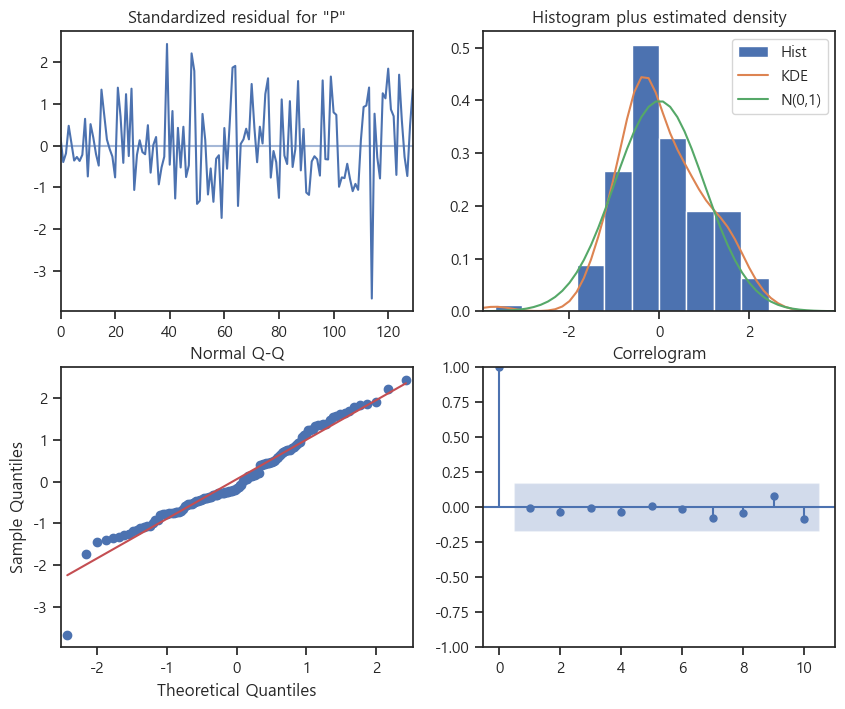

In [ ]:
ARIMA_model_fit.plot_diagnostics(figsize=(10,8));

- 융-박스 테스트
  + 처음 두 값을 제외하고 모두 0.05보다 큼
  + 지연3부터 상관관계가 없다는 결론 내림

In [ ]:
residuals = ARIMA_model_fit.resid
acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,6.551335,0.010481
2,6.677808,0.035476
3,6.954707,0.073356
4,7.748493,0.101238
5,8.392336,0.135898
6,8.678298,0.192495
7,9.492646,0.219193
8,9.730885,0.284425
9,9.741190,0.371841
10,11.532589,0.317555


### 예측 테스트
- 단순한 계절 예측
- ARIMA 모델 예측

In [ ]:
test = df.iloc[-12:]

test['naive_seasonal'] = df['Passengers'].iloc[120:132].values
ARIMA_pred = ARIMA_model_fit.get_prediction(132, 143).predicted_mean

test['ARIMA_pred'] = ARIMA_pred
test

,Month,Passengers,naive_seasonal,ARIMA_pred
132,1960-01,417,360,422.331388
133,1960-02,391,342,410.649193
134,1960-03,419,406,461.838574
135,1960-04,461,396,457.788882
136,1960-05,472,420,481.662891
137,1960-06,535,472,531.049169
138,1960-07,622,548,606.144556
139,1960-08,606,559,615.452025
140,1960-09,508,463,525.629516
141,1960-10,461,407,467.148092


## SARIMA 모델 적합

### ADF 확인

In [ ]:
ad_fuller_result = adfuller(df['Passengers'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


In [ ]:
df_diff = np.diff(df['Passengers'], n=1)

ad_fuller_result = adfuller(df_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.8292668241699994
p-value: 0.0542132902838255


In [ ]:
df_diff_seasonal_diff = np.diff(df_diff, n=12)

ad_fuller_result = adfuller(df_diff_seasonal_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -17.62486236018866
p-value: 3.823046855895306e-30


### SARIMA 모델 적합
- 한 번의 차분, d = 1과 한번의 계절적 차분 D = 1 수행

In [ ]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
Ps = range(0, 4, 1)
Qs = range(0, 4, 1)

SARIMA_order_list = list(product(ps, qs, Ps, Qs))

train = df['Passengers'][:-12]

d = 1
D = 1
s = 12

SARIMA_result_df = optimize_SARIMA(train, SARIMA_order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/256 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 1, 1, 2)",892.243222
1,"(2, 1, 2, 1)",893.537177
2,"(2, 1, 1, 3)",894.097082
3,"(1, 0, 1, 2)",894.290289
4,"(0, 1, 1, 2)",894.991883
...,...,...
251,"(0, 0, 2, 0)",906.940147
252,"(3, 2, 0, 3)",907.181875
253,"(0, 0, 3, 2)",907.448696
254,"(0, 0, 3, 0)",908.742583


- AIC가 가장 낮은 모델은 $SARIMA(2, 1, 1)(1, 1, 2)_{12}$ 모델

In [ ]:
SARIMA_model = SARIMAX(train, order=(2,1,1), seasonal_order=(1,1,2,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                              Passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                -439.122
Date:                                 Fri, 03 Apr 2026   AIC                            892.243
Time:                                         14:18:50   BIC                            911.697
Sample:                                              0   HQIC                           900.143
                                                 - 132                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2658      0.085    -14.903      0.000      -1.432      -1

## 잔차 분석

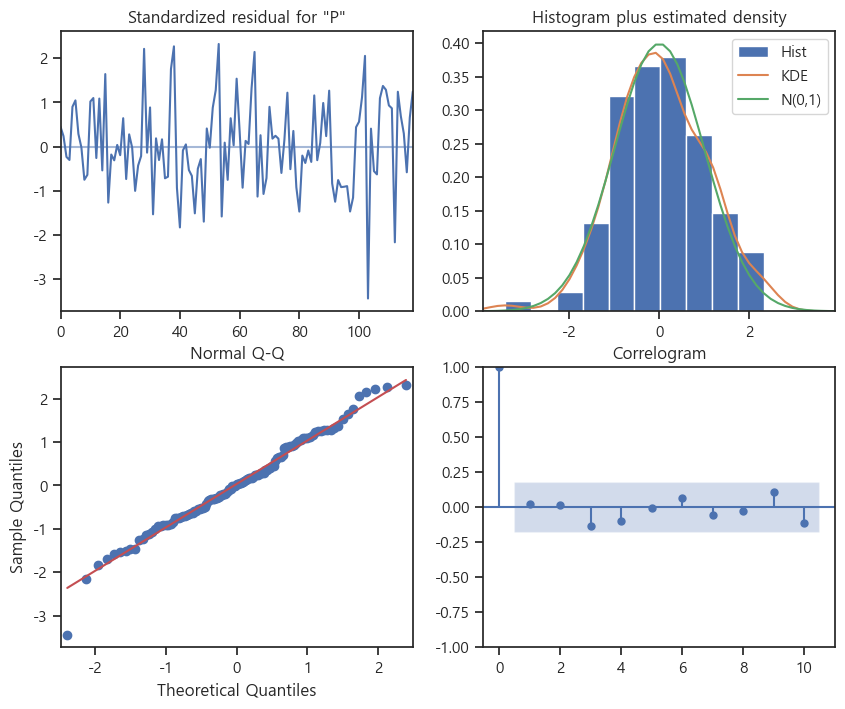

In [ ]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

In [ ]:
residuals = SARIMA_model_fit.resid
acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,0.004984,0.943718
2,0.740152,0.690682
3,1.009888,0.798859
4,1.223080,0.874284
5,1.438858,0.920016
6,1.703872,0.944822
7,2.293584,0.941823
8,2.712971,0.951060
9,2.728622,0.974090
10,4.972129,0.893032


## 예측 테스트

In [ ]:
SARIMA_pred = SARIMA_model_fit.get_prediction(132, 143).predicted_mean
test['SARIMA_pred'] = SARIMA_pred

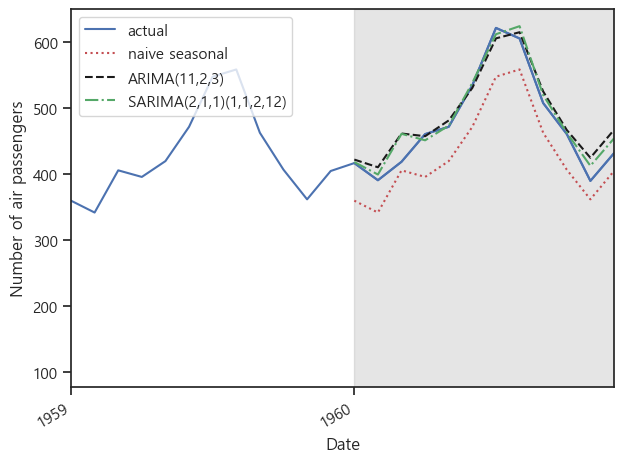

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.plot(test['Passengers'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(11,2,3)')
ax.plot(test['SARIMA_pred'], 'g-.', label='SARIMA(2,1,1)(1,1,2,12)')

ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')
ax.axvspan(132, 143, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
ax.set_xlim(120, 143)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 기본 모델과 결과 비교

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_naive_seasonal = mape(test['Passengers'], test['naive_seasonal'])
mape_ARIMA = mape(test['Passengers'], test['ARIMA_pred'])
mape_SARIMA = mape(test['Passengers'], test['SARIMA_pred'])

print(mape_naive_seasonal, mape_ARIMA, mape_SARIMA)

9.987532920823485 3.841305062456637 2.863946467882572


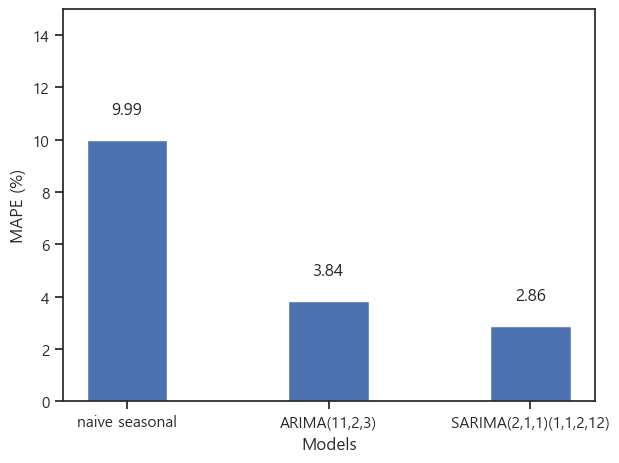

In [ ]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(11,2,3)', 'SARIMA(2,1,1)(1,1,2,12)']
y = [mape_naive_seasonal, mape_ARIMA, mape_SARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()
plt.show()